In [ ]:
import xarray as xr


dt = xr.open_dataset("/glade/derecho/scratch/bgong/amip_s2s_ensembles/20190502/ensemble_20190502_seed0.nc")
if "time" in dt.dims:
    dt = dt.rename({"time": "deltatime"})

In [3]:
dt["2m_temperature"]

<xarray.DataArray '2m_temperature' (member: 4, time: 46, lat: 180, lon: 360)> Size: 48MB
[11923200 values with dtype=float32]
Coordinates:
  * member   (member) int32 16B 0 1 2 3
  * time     (time) datetime64[ns] 368B 2019-05-02 2019-05-03 ... 2019-06-16
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5

In [2]:
variable = "2m_temperature"
variable_fcst = "PRATEsfc_24h"
era5 = xr.open_mfdataset(
    f"/glade/derecho/scratch/bgong/era5/{variable}/*_180x360.nc",
    chunks={},
    engine="netcdf4",
).rename({"lat": "latitude", "lon": "longitude"})

In [3]:
era5


<xarray.Dataset> Size: 3GB
Dimensions:         (time: 10228, latitude: 180, longitude: 360)
Coordinates:
  * time            (time) datetime64[ns] 82kB 2018-01-01 ... 2024-12-31T18:0...
  * longitude       (longitude) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * latitude        (latitude) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
Data variables:
    2m_temperature  (time, latitude, longitude) float32 3GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    CDI:                       Climate Data Interface version 2.5.0 (https://...
    Conventions:               CF-1.6
    history:                   Tue Nov 11 16:01:02 2025: cdo -P 96 remapcon,r...
    CDO:                       Climate Data Operators version 2.5.0 (https://...
    cdo_openmp_thread_number:  96

In [79]:
era5 = era5.rename({"latitude": "lat", "longitude": "lon"})

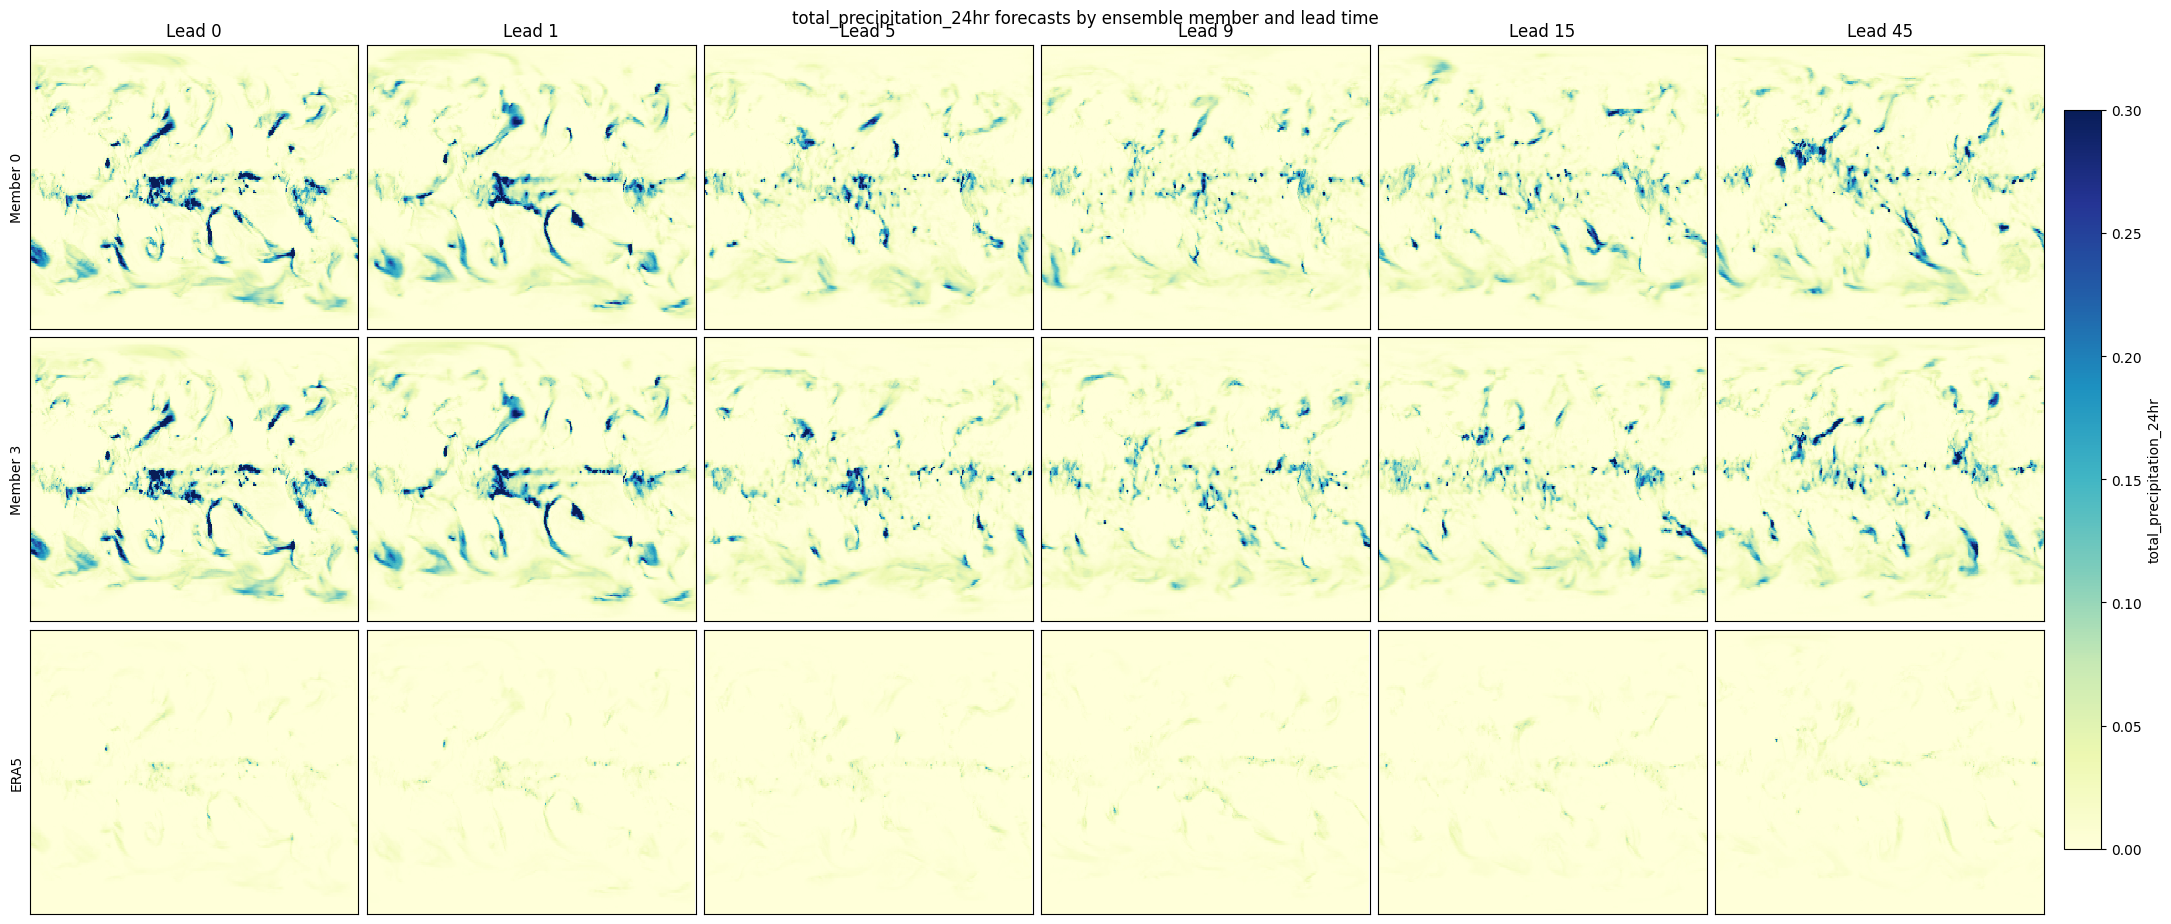

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

lead_times = [0, 1, 5, 9, 15, 45]
ensemble_members = [0, 3]

fcst = dt[variable_fcst] if isinstance(dt, xr.Dataset) else dt
truth = era5[variable] if isinstance(era5, xr.Dataset) else era5


def find_name(obj, candidates):
    for name in obj.dims:
        if name.lower() in candidates:
            return name
    for name in obj.coords:
        if name.lower() in candidates:
            return name
    return None


lat_name = find_name(fcst, {"lat", "latitude"}) or find_name(truth, {"lat", "latitude"})
lon_name = find_name(fcst, {"lon", "longitude"}) or find_name(truth, {"lon", "longitude"})
member_name = find_name(fcst, {"member", "number", "ensemble", "ens"})
lead_name = find_name(fcst, {"time", "deltatime", "valid_time", "lead_time", "step", "forecast_hour"})
truth_time_name = find_name(truth, {"time", "valid_time"})

if member_name is None:
    raise ValueError(f"Could not find an ensemble dimension in forecast dims {fcst.dims}")
if lead_name is None:
    raise ValueError(f"Could not find a lead-time dimension in forecast dims {fcst.dims}")
if lat_name is None or lon_name is None:
    raise ValueError("Could not find latitude/longitude dimensions in the forecast or ERA5 data")
if truth_time_name is None:
    raise ValueError(f"Could not find a time dimension in ERA5 dims {truth.dims}")

if fcst.sizes[member_name] < 4:
    raise ValueError(f"Expected at least 4 ensemble members, found {fcst.sizes[member_name]}")
if fcst.sizes[lead_name] <= max(lead_times):
    raise ValueError(
        f"Forecast lead axis '{lead_name}' has size {fcst.sizes[lead_name]}, which is too small for lead times {lead_times}"
    )

selected_forecasts = []
selected_truths = []

for lead in lead_times:
    forecast_lead = fcst.isel({lead_name: lead}).squeeze(drop=True)
    selected_forecasts.append(forecast_lead)

    forecast_time = forecast_lead.coords.get(lead_name, None)
    if forecast_time is None:
        forecast_time = fcst[lead_name].isel({lead_name: lead}).values
    else:
        forecast_time = forecast_time.values

    truth_lead = truth.sel({truth_time_name: forecast_time}, method="nearest")
    selected_truths.append(truth_lead.squeeze(drop=True))

all_fields = []

for forecast_lead, truth_lead in zip(selected_forecasts, selected_truths):
    for member in ensemble_members:
        all_fields.append(forecast_lead.isel({member_name: member}).values)
    all_fields.append(truth_lead.values)

# vmin = np.nanmin([np.nanmin(field) for field in all_fields])
# vmax = np.nanmax([np.nanmax(field) for field in all_fields])
vmin = 0.0
vmax = 0.3

row_labels = [f"Member {m}" for m in ensemble_members] + ["ERA5"]

fig, axes = plt.subplots(
    len(ensemble_members) + 1,
    len(lead_times),
    figsize=(3.6 * len(lead_times), 3.0 * (len(ensemble_members) + 1)),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

for ax, lead in zip(axes[0], lead_times):
    ax.set_title(f"Lead {lead}")

mesh = None
for col, (lead, forecast_lead, truth_lead) in enumerate(zip(lead_times, selected_forecasts, selected_truths)):
    for row, member in enumerate(ensemble_members):
        ax = axes[row, col]
        field = forecast_lead.isel({member_name: member}).squeeze(drop=True)
        mesh = ax.pcolormesh(
            field[lon_name],
            field[lat_name],
            field * 24 * 36,
            shading="auto",
            cmap="YlGnBu",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(row_labels[row])

    ax = axes[-1, col]
    mesh = ax.pcolormesh(
        truth_lead[lon_name],
        truth_lead[lat_name],
        truth_lead,
        shading="auto",
        cmap="YlGnBu",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_xticks([])
    ax.set_yticks([])
    if col == 0:
        ax.set_ylabel(row_labels[-1])

cbar = fig.colorbar(mesh, ax=axes.ravel().tolist(), shrink=0.85, pad=0.01)
cbar.set_label(variable)
fig.suptitle(f"{variable} forecasts by ensemble member and lead time", y=1.01)
plt.show()

In [1]:
import glob
import os
import numpy as np
import xarray as xr

pattern = "/glade/derecho/scratch/bgong/amip_s2s_ensembles/*/*2020*seed0.nc"
files = sorted(glob.glob(pattern))

if not files:
    raise FileNotFoundError(f"No files matched: {pattern}")

print(f"Found {len(files)} files")
print(files[:3])

datasets = []
for fp in files:
    ds = xr.open_dataset(fp, chunks={}, engine="netcdf4")

    # Use parent folder name as initialization time (expected YYYYMMDD).
    init_str = os.path.basename(os.path.dirname(fp))
    try:
        init_val = np.datetime64(f"{init_str[:4]}-{init_str[4:6]}-{init_str[6:8]}")
    except Exception:
        init_val = init_str

    ds = ds.expand_dims(intal_time=[init_val])

    # Replace absolute valid times with lead-time offsets [0D, 1D, ..., nD].
    n_time = ds.sizes.get("time", 0)
    if n_time > 0:
        ds = ds.assign_coords(time=np.arange(n_time).astype("timedelta64[D]"))

    print("ds['time']:", ds["time"])
    datasets.append(ds)

# Fast concat: skip expensive coordinate re-alignment.
ds_all = xr.concat(
    datasets,
    dim="intal_time",
    data_vars="minimal",
    coords="minimal",
    compat="override",
    join="override",
    combine_attrs="override",
)

ds_all

Found 24 files
['/glade/derecho/scratch/bgong/amip_s2s_ensembles/20200502/ensemble_20200502_seed0.nc', '/glade/derecho/scratch/bgong/amip_s2s_ensembles/20200506/ensemble_20200506_seed0.nc', '/glade/derecho/scratch/bgong/amip_s2s_ensembles/20200509/ensemble_20200509_seed0.nc']
ds['time']: <xarray.DataArray 'time' (time: 46)> Size: 368B
array([      0,   86400,  172800,  259200,  345600,  432000,  518400,  604800,
        691200,  777600,  864000,  950400, 1036800, 1123200, 1209600, 1296000,
       1382400, 1468800, 1555200, 1641600, 1728000, 1814400, 1900800, 1987200,
       2073600, 2160000, 2246400, 2332800, 2419200, 2505600, 2592000, 2678400,
       2764800, 2851200, 2937600, 3024000, 3110400, 3196800, 3283200, 3369600,
       3456000, 3542400, 3628800, 3715200, 3801600, 3888000],
      dtype='timedelta64[s]')
Coordinates:
  * time     (time) timedelta64[s] 368B 0 days 1 days 2 days ... 44 days 45 days
ds['time']: <xarray.DataArray 'time' (time: 46)> Size: 368B
array([      0,   8640

<xarray.Dataset> Size: 173GB
Dimensions:                  (intal_time: 24, member: 4, time: 46, lat: 180,
                              lon: 360, plev: 26)
Coordinates:
  * intal_time               (intal_time) datetime64[s] 192B 2020-05-02 ... 2...
  * member                   (member) int32 16B 0 1 2 3
  * plev                     (plev) float64 208B 500.0 700.0 ... 9.75e+04 1e+05
  * lat                      (lat) float64 1kB -89.5 -88.5 -87.5 ... 88.5 89.5
  * lon                      (lon) float64 3kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
  * time                     (time) timedelta64[s] 368B 0 days ... 45 days
Data variables: (12/26)
    skin_temperature         (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    surface_pressure         (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    2m_temperature           (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    2m_specific_humidity     (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    10m_u_component_of_wind  (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    10m_v_component_of_wind  (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    ...                       ...
    hcc_24h                  (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    lcc_24h                  (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    mcc_24h                  (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    mn2t_24h                 (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    mx2t_24h                 (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    mxtpr_24h                (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.8
    source:       amip S2S ensemble rollout
    start_date:   2020-05-02T00:00:00
    n_ensemble:   4
    frequency:    day
    grid_label:   gn

In [4]:
dt = ds_all
if "time" in dt.dims:
    dt = dt.rename({"time": "deltatime"})

In [5]:
dt

<xarray.Dataset> Size: 173GB
Dimensions:                  (intal_time: 24, member: 4, deltatime: 46,
                              lat: 180, lon: 360, plev: 26)
Coordinates:
  * intal_time               (intal_time) datetime64[s] 192B 2020-05-02 ... 2...
  * member                   (member) int32 16B 0 1 2 3
  * plev                     (plev) float64 208B 500.0 700.0 ... 9.75e+04 1e+05
  * lat                      (lat) float64 1kB -89.5 -88.5 -87.5 ... 88.5 89.5
  * lon                      (lon) float64 3kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
  * deltatime                (deltatime) timedelta64[s] 368B 0 days ... 45 days
Data variables: (12/26)
    skin_temperature         (intal_time, member, deltatime, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    surface_pressure         (intal_time, member, deltatime, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    2m_temperature           (intal_time, member, deltatime, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    2m_specific_humidity     (intal_time, member, deltatime, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    10m_u_component_of_wind  (intal_time, member, deltatime, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    10m_v_component_of_wind  (intal_time, member, deltatime, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    ...                       ...
    hcc_24h                  (intal_time, member, deltatime, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    lcc_24h                  (intal_time, member, deltatime, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    mcc_24h                  (intal_time, member, deltatime, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    mn2t_24h                 (intal_time, member, deltatime, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    mx2t_24h                 (intal_time, member, deltatime, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    mxtpr_24h                (intal_time, member, deltatime, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.8
    source:       amip S2S ensemble rollout
    start_date:   2020-05-02T00:00:00
    n_ensemble:   4
    frequency:    day
    grid_label:   gn

In [6]:
era5

<xarray.Dataset> Size: 3GB
Dimensions:         (time: 10228, latitude: 180, longitude: 360)
Coordinates:
  * time            (time) datetime64[ns] 82kB 2018-01-01 ... 2024-12-31T18:0...
  * longitude       (longitude) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * latitude        (latitude) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
Data variables:
    2m_temperature  (time, latitude, longitude) float32 3GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    CDI:                       Climate Data Interface version 2.5.0 (https://...
    Conventions:               CF-1.6
    history:                   Tue Nov 11 16:01:02 2025: cdo -P 96 remapcon,r...
    CDO:                       Climate Data Operators version 2.5.0 (https://...
    cdo_openmp_thread_number:  96

In [67]:
variable = "2m_temperature"
era5 = xr.open_mfdataset(
    f"/glade/derecho/scratch/bgong/era5/{variable}/*_180x360.nc",
    chunks={},
    engine="netcdf4",
).rename({"lat": "latitude", "lon": "longitude"})

In [57]:
era5

<xarray.Dataset> Size: 3GB
Dimensions:         (time: 10228, latitude: 180, longitude: 360)
Coordinates:
  * time            (time) datetime64[ns] 82kB 2018-01-01 ... 2024-12-31T18:0...
  * longitude       (longitude) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * latitude        (latitude) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
Data variables:
    2m_temperature  (time, latitude, longitude) float32 3GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    CDI:                       Climate Data Interface version 2.5.0 (https://...
    Conventions:               CF-1.6
    history:                   Tue Nov 11 16:01:02 2025: cdo -P 96 remapcon,r...
    CDO:                       Climate Data Operators version 2.5.0 (https://...
    cdo_openmp_thread_number:  96

In [85]:
import numpy as np
import xarray as xr

if "temperature" not in ds_all:
    raise KeyError(
        "'temperature' not found in ds_all. "
        f"Available variables include: {list(ds_all.data_vars)[:10]}"
    )

fcst = dt["2m_temperature"]
obs = era5["2m_temperature"]

# Normalize coordinate names to simplify alignment.
fcst = fcst.rename({"latitude": "lat", "longitude": "lon"}) if "latitude" in fcst.dims or "longitude" in fcst.dims else fcst
obs = obs.rename({"latitude": "lat", "longitude": "lon"}) if "latitude" in obs.dims or "longitude" in obs.dims else obs

if "deltatime" in fcst.dims:
    fcst = fcst.rename({"deltatime": "time"})


def sort_and_drop_duplicate_time(da: xr.DataArray) -> xr.DataArray:
    if "time" in da.dims and "time" in da.indexes:
        da = da.sortby("time")
        da = da.isel(time=~da.indexes["time"].duplicated())
    return da


fcst = sort_and_drop_duplicate_time(fcst)
obs = sort_and_drop_duplicate_time(obs)

# Align on shared coordinates (time/lat/lon and any others in common).
fcst_aligned, obs_aligned = xr.align(fcst, obs, join="inner")

if "lat" not in fcst_aligned.dims or "lon" not in fcst_aligned.dims:
    raise ValueError(f"Expected lat/lon dims, got {fcst_aligned.dims}")

lat_weights = np.cos(np.deg2rad(fcst_aligned["lat"]))
error2 = (fcst_aligned - obs_aligned) ** 2

# Area-like weighting: latitude weights applied across the lat/lon reduction.
weighted_mse = error2.weighted(lat_weights).mean(dim=["lat", "lon"], skipna=True)

# Scalar RMSE over all remaining dimensions (e.g., time/member).
rmse_da = np.sqrt(weighted_mse.mean(skipna=True))
lat_weighted_rmse = float(rmse_da.compute().values)
print(f"Latitude-weighted RMSE: {lat_weighted_rmse:.6f}")

lat_weighted_rmse

Latitude-weighted RMSE: nan


nan

In [72]:
dt

<xarray.Dataset> Size: 173GB
Dimensions:                  (intal_time: 24, member: 4, time: 46, lat: 180,
                              lon: 360, plev: 26)
Coordinates:
  * intal_time               (intal_time) datetime64[s] 192B 2020-05-02 ... 2...
  * member                   (member) int32 16B 0 1 2 3
  * time                     (time) datetime64[ns] 368B 2020-05-02 ... 2020-0...
  * plev                     (plev) float64 208B 500.0 700.0 ... 9.75e+04 1e+05
  * lat                      (lat) float64 1kB -89.5 -88.5 -87.5 ... 88.5 89.5
  * lon                      (lon) float64 3kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
Data variables: (12/26)
    skin_temperature         (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    surface_pressure         (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    2m_temperature           (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    2m_specific_humidity     (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    10m_u_component_of_wind  (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    10m_v_component_of_wind  (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    ...                       ...
    hcc_24h                  (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    lcc_24h                  (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    mcc_24h                  (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    mn2t_24h                 (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    mx2t_24h                 (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
    mxtpr_24h                (intal_time, member, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1, 6, 23, 90), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.8
    source:       amip S2S ensemble rollout
    start_date:   2020-05-02T00:00:00
    n_ensemble:   4
    frequency:    day
    grid_label:   gn

In [8]:
import numpy as np
import xarray as xr

var_name = "2m_temperature"
fcst_all = dt[var_name]
obs = era5[var_name]

# Normalize coordinate names.
fcst_all = fcst_all.rename({"latitude": "lat", "longitude": "lon"}) if "latitude" in fcst_all.dims or "longitude" in fcst_all.dims else fcst_all
obs = obs.rename({"latitude": "lat", "longitude": "lon"}) if "latitude" in obs.dims or "longitude" in obs.dims else obs

lead_dim = "deltatime" if "deltatime" in fcst_all.dims else "time"

# Ensure unique time indexes before selection.
def sort_and_drop_duplicate_time(da: xr.DataArray, time_dim: str = "time") -> xr.DataArray:
    if time_dim in da.dims and time_dim in da.indexes:
        da = da.sortby(time_dim)
        da = da.isel({time_dim: ~da.indexes[time_dim].duplicated()})
    return da

obs = sort_and_drop_duplicate_time(obs, "time")

member_dim = next((d for d in ["member", "number", "ensemble", "ens"] if d in fcst_all.dims), None)
if member_dim is None:
    raise ValueError(f"Could not find ensemble dimension in forecast dims: {fcst_all.dims}")

lat_dim = "lat" if "lat" in fcst_all.dims else "latitude"
lon_dim = "lon" if "lon" in fcst_all.dims else "longitude"

if "intal_time" in fcst_all.dims:
    init_vals = fcst_all["intal_time"].values
else:
    init_vals = np.array([0])

# Resume support: keep previously computed entries if available.
if "crps_by_init" in globals() and isinstance(crps_by_init, list):
    crps_by_init_work = list(crps_by_init)
else:
    crps_by_init_work = []

done_init_keys = set()
for da_prev in crps_by_init_work:
    if "intal_time" in da_prev.coords and da_prev.sizes.get("intal_time", 0) > 0:
        done_init_keys.add(str(np.asarray(da_prev["intal_time"].values)[0]))

for init_val in init_vals:
    init_key = str(init_val)
    # if init_key in done_init_keys:
    #     print(f"Skipping completed intal_time = {init_key}")
    #     continue

    print(f"Processing intal_time = {init_key}")

    fcst = fcst_all.sel(intal_time=init_key)
    print(f"fcast  intial date", fcst["intal_time"].values)

    # Interpolate ERA5 to this forecast grid once per intal_time.
    obs_on_grid = obs.interp({lat_dim: fcst[lat_dim], lon_dim: fcst[lon_dim]}, method="linear")

    # Build absolute valid times from init_time + lead offsets so dtype matches ERA5 datetime64.
    lead_vals = np.asarray(fcst[lead_dim].values)
    if np.issubdtype(lead_vals.dtype, np.timedelta64):
        lead_offsets = lead_vals.astype("timedelta64[ns]")
    elif np.issubdtype(lead_vals.dtype, np.number):
        # Most files encode lead offsets as seconds (0, 86400, 172800, ...).
        lead_offsets = lead_vals.astype("timedelta64[s]").astype("timedelta64[ns]")
    else:
        lead_offsets = xr.to_timedelta(lead_vals).values.astype("timedelta64[ns]")

    init_time = np.datetime64(init_val, "ns")
    valid_times = init_time + lead_offsets
    valid_da = xr.DataArray(valid_times, dims=[lead_dim], coords={lead_dim: fcst[lead_dim].values})

    obs_on_time = obs_on_grid.sel(time=valid_da, method="nearest")
    obs_on_time = obs_on_time.assign_coords({lead_dim: fcst[lead_dim].values})

    matched_times = np.asarray(obs_on_time["time"].values).astype("datetime64[ns]")
    delta_h = (matched_times - valid_times).astype("timedelta64[h]").astype(int)
    print("valid_times", valid_times[:1])
    print(f"time mismatch (hours): min={delta_h.min()}, max={delta_h.max()}")

    # Load once per intal_time to avoid repeated Dask scheduling in inner loop.
    fcst_np = np.asarray(fcst.transpose(lead_dim, member_dim, lat_dim, lon_dim).load().values)
    obs_np = np.asarray(obs_on_time.transpose(lead_dim, lat_dim, lon_dim).load().values)
    lat_vals = np.asarray(fcst[lat_dim].values)

    crps_vals = []
    crps_times = np.asarray(fcst[lead_dim].values)

    for i in range(fcst_np.shape[0]):
        f = fcst_np[i]  # (member, lat, lon)
        o = obs_np[i]   # (lat, lon)

        # CRPS = E|X - y| - 0.5 E|X - X'|
        with np.errstate(invalid="ignore"):
            term1 = np.nanmean(np.abs(f - o[None, :, :]), axis=0)
            pairwise = np.abs(f[:, None, :, :] - f[None, :, :, :])
            term2 = 0.5 * np.nanmean(pairwise, axis=(0, 1))
        crps_field = term1 - term2

        # Latitude-weighted domain mean for this lead time.
        w_lat = np.cos(np.deg2rad(lat_vals))[:, None]
        valid = np.isfinite(crps_field)
        denom = np.nansum(w_lat * valid)
        crps_t = np.nan if denom == 0 else np.nansum(crps_field * w_lat) / denom
        crps_vals.append(float(crps_t))

    
    da = xr.DataArray(np.array(crps_vals), coords={lead_dim: crps_times}, dims=[lead_dim], name="crps")
    print("CRPS by lead:", da.values)
    if "intal_time" in fcst_all.dims:
        da = da.expand_dims(intal_time=[init_val])

    crps_by_init_work.append(da)
    done_init_keys.add(init_key)

# Expose progress list in notebook state for resume.
crps_by_init = crps_by_init_work

# CRPS per intal_time and lead dimension.
crps_by_time_by_init = xr.concat(crps_by_init, dim="intal_time") if len(crps_by_init) > 1 else crps_by_init[0].expand_dims(intal_time=[init_vals[0]])

# Average across intal_time.
crps_by_time = crps_by_time_by_init.mean(dim="intal_time", skipna=True)

print(f"Mean CRPS over intal_time ({var_name}) = {float(crps_by_time.mean(skipna=True)):.6f}")
print(f"intal_time computed: {len(crps_by_init)} / {len(init_vals)}")
print(f"NaN lead-times after averaging: {int(np.isnan(crps_by_time.values).sum())} / {crps_by_time.size}")

crps_by_time

Processing intal_time = 2020-05-02T00:00:00
fcast  intial date 2020-05-02T00:00:00
valid_times ['2020-05-02T00:00:00.000000000']
time mismatch (hours): min=0, max=0


/glade/derecho/scratch/bgong/tmp/ipykernel_18640/1624848605.py:96: RuntimeWarning: Mean of empty slice
  term1 = np.nanmean(np.abs(f - o[None, :, :]), axis=0)


CRPS by lead: [0.28512557 0.5356955  0.64207433 0.7456055  0.84612489 0.92368772
 1.02085379 1.07954035 1.15175852 1.16120523 1.29684924 1.38816036
 1.3534203  1.29032017 1.23794192 1.22967966 1.245954   1.36984854
 1.392861   1.39895537 1.42147915 1.39802757 1.43229581 1.4072245
 1.35732188 1.3541161  1.35522319 1.4511155  1.44355832 1.39435151
 1.30576978 1.27822515 1.2468459  1.26532452 1.25126007 1.24389503
 1.23300947 1.27164519 1.34057223 1.33683861 1.26089525 1.2508012
 1.27602069 1.27690042 1.29580853 1.36613769]
Processing intal_time = 2020-05-06T00:00:00
fcast  intial date 2020-05-06T00:00:00
valid_times ['2020-05-06T00:00:00.000000000']
time mismatch (hours): min=0, max=0


/glade/derecho/scratch/bgong/tmp/ipykernel_18640/1624848605.py:96: RuntimeWarning: Mean of empty slice
  term1 = np.nanmean(np.abs(f - o[None, :, :]), axis=0)


CRPS by lead: [0.28579828 0.52306799 0.66430679 0.77259739 0.84163935 0.92859833
 1.03455352 1.13522593 1.17467757 1.15534213 1.12661763 1.12389068
 1.17074462 1.30136546 1.35261782 1.32453411 1.3247748  1.33949004
 1.31118609 1.3685455  1.32927201 1.3139453  1.35455088 1.45364929
 1.40951589 1.3312805  1.29474283 1.27630968 1.24093788 1.27064821
 1.28973893 1.29271491 1.31130292 1.36305979 1.39592528 1.3342991
 1.26953466 1.25619435 1.22073759 1.21891304 1.23616638 1.32503194
 1.42785533 1.44004404 1.41450621 1.4481998 ]
Processing intal_time = 2020-05-09T00:00:00
fcast  intial date 2020-05-09T00:00:00
valid_times ['2020-05-09T00:00:00.000000000']
time mismatch (hours): min=0, max=0


...

CRPS by lead: [0.29023933 0.53664869 0.64738433 0.73784463 0.8121295  0.90012748
 0.95963277 1.05212318 1.15774187 1.24417408 1.24645567 1.19565948
 1.153638   1.19061798 1.21949071 1.22451494 1.29651159 1.32585793
 1.37480605 1.44032343 1.43010922 1.42129894 1.39828964 1.36094702
 1.30896129 1.31423511 1.33809382 1.32301179 1.3387106  1.31762897
 1.28268356 1.31380885 1.31094395 1.34122363 1.37668282 1.38886701
 1.4066504  1.44867342 1.51195099 1.50441014 1.45915695 1.4625336
 1.4357845  1.37745933 1.41642213 1.47871718]
Processing intal_time = 2020-07-18T00:00:00
fcast  intial date 2020-07-18T00:00:00
valid_times ['2020-07-18T00:00:00.000000000']
time mismatch (hours): min=0, max=0


/glade/derecho/scratch/bgong/tmp/ipykernel_18640/1624848605.py:96: RuntimeWarning: Mean of empty slice
  term1 = np.nanmean(np.abs(f - o[None, :, :]), axis=0)


CRPS by lead: [0.29263747 0.5373586  0.65975213 0.73851323 0.83949635 0.92498753
 1.06076727 1.14083706 1.1538201  1.15511928 1.10652566 1.13313392
 1.12455965 1.15921712 1.2198203  1.2944349  1.35635161 1.37183959
 1.32492145 1.34649519 1.28471442 1.25801496 1.3062546  1.36514202
 1.35180856 1.37839659 1.4210042  1.37604311 1.35056458 1.32151904
 1.35622155 1.38761817 1.38689728 1.38315362 1.39240631 1.38750099
 1.35884721 1.34678564 1.3439418  1.32430849 1.34058055 1.398054
 1.47192282 1.53965489 1.55245226 1.50847451]
Processing intal_time = 2020-07-22T00:00:00
fcast  intial date 2020-07-22T00:00:00
valid_times ['2020-07-22T00:00:00.000000000']
time mismatch (hours): min=0, max=0
CRPS by lead: [0.28741769 0.53825974 0.65411917 0.74770523 0.84269053 0.91587984
 0.96251084 1.04061383 1.06580263 1.14871638 1.18984905 1.28780699
 1.37757643 1.39084621 1.36870968 1.38517458 1.34031105 1.27917166
 1.2727916  1.31131497 1.33816875 1.38761765 1.40554211 1.31538461
 1.30695247 1.29196119 1.3

/glade/derecho/scratch/bgong/tmp/ipykernel_18640/1624848605.py:96: RuntimeWarning: Mean of empty slice
  term1 = np.nanmean(np.abs(f - o[None, :, :]), axis=0)


<xarray.DataArray 'crps' (deltatime: 46)> Size: 368B
array([0.29048436, 0.53886031, 0.65174064, 0.74687973, 0.83387739,
       0.91440832, 0.99731152, 1.07357412, 1.13000139, 1.17179082,
       1.20859025, 1.23776557, 1.26064855, 1.28219492, 1.30027992,
       1.30134797, 1.3156456 , 1.33792316, 1.34894824, 1.3486342 ,
       1.34983699, 1.35860553, 1.36557337, 1.37198331, 1.37270942,
       1.37483804, 1.3821506 , 1.37172759, 1.37157277, 1.3674807 ,
       1.36108248, 1.36488572, 1.36636726, 1.36549612, 1.36479119,
       1.37577398, 1.38216356, 1.37459702, 1.37947565, 1.38238286,
       1.3799747 , 1.37997658, 1.39792461, 1.41352303, 1.41199674,
       1.4143878 ])
Coordinates:
  * deltatime  (deltatime) timedelta64[s] 368B 0 days 1 days ... 44 days 45 days

In [9]:

crps_by_time

<xarray.DataArray 'crps' (deltatime: 46)> Size: 368B
array([0.29048436, 0.53886031, 0.65174064, 0.74687973, 0.83387739,
       0.91440832, 0.99731152, 1.07357412, 1.13000139, 1.17179082,
       1.20859025, 1.23776557, 1.26064855, 1.28219492, 1.30027992,
       1.30134797, 1.3156456 , 1.33792316, 1.34894824, 1.3486342 ,
       1.34983699, 1.35860553, 1.36557337, 1.37198331, 1.37270942,
       1.37483804, 1.3821506 , 1.37172759, 1.37157277, 1.3674807 ,
       1.36108248, 1.36488572, 1.36636726, 1.36549612, 1.36479119,
       1.37577398, 1.38216356, 1.37459702, 1.37947565, 1.38238286,
       1.3799747 , 1.37997658, 1.39792461, 1.41352303, 1.41199674,
       1.4143878 ])
Coordinates:
  * deltatime  (deltatime) timedelta64[s] 368B 0 days 1 days ... 44 days 45 days

In [ ]:
expected_inits = int(dt.sizes.get("intal_time", 1))
done_inits = len(crps_by_init) if "crps_by_init" in globals() else 0
print(f"Computed init count: {done_inits}/{expected_inits}")

if done_inits == expected_inits and done_inits > 0:
    crps_by_time_by_init = xr.concat(crps_by_init, dim="intal_time")
    crps_by_time = crps_by_time_by_init.mean(dim="intal_time", skipna=True)
    print(f"Final mean CRPS over intal_time: {float(crps_by_time.mean(skipna=True)):.6f}")
else:
    print("CRPS-by-init list is incomplete; rerun Cell 20 to finish all intal_time values.")

Computed init count: 3/24
CRPS-by-init list is incomplete; rerun Cell 20 to finish all intal_time values.


In [ ]:
fcst = dt["2m_temperature"] 

obs = era5.sel(time=fcst["time"], method="nearest") 

In [28]:
obs


<xarray.DataArray '2m_temperature' (time: 46, latitude: 180, longitude: 360)> Size: 12MB
dask.array<getitem, shape=(46, 180, 360), dtype=float32, chunksize=(1, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 368B 2019-05-02 2019-05-03 ... 2019-06-16
  * longitude  (longitude) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
  * latitude   (latitude) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
Attributes:
    long_name:   2 metre temperature
    units:       K
    short_name:  t2m

In [10]:
out_path = "/glade/work/bgong/benchmark-dev/crps_by_time.nc"
crps_by_time.to_dataset(name="crps").to_netcdf(out_path)
print(f"Saved: {out_path}")

Saved: /glade/work/bgong/benchmark-dev/crps_by_time.nc
